Dimensiones: (15568, 50)
   Puesto Ciudad  Código    Ciudad            Proyecto              Vende  \
0              1   63662  Medellin             Sirius*        Puerta Inm.   
1              1  501420    Bogota      Verde Imperial    Buenvivir Cons.   
2              2  501350    Bogota          Bóreas 175  Const. Las Galias   
3              3  501419    Bogota      Bóreas 175 - 2  Const. Las Galias   
4              4  501359    Bogota  Vitália Carrera 50  Const. Las Galias   

           Construye           Dirección          Zona    Sub Zona  Estrato  \
0            Conarte    Cr. 50 # 53- 107  Norte No VIS  Copacabana        4   
1    Buenvivir Cons.  Cl. 153 # 106 - 88          Suba     Campiña        3   
2  Const. Las Galias     Cl. 175 # 22-10         Norte     Maranta        3   
3  Const. Las Galias   Cl. 175 # 22 - 10         Norte     Maranta        3   
4  Const. Las Galias      Cr. 50 # 5C-81        Centro     C/marca        3   

   ... Calificación % valores del fil

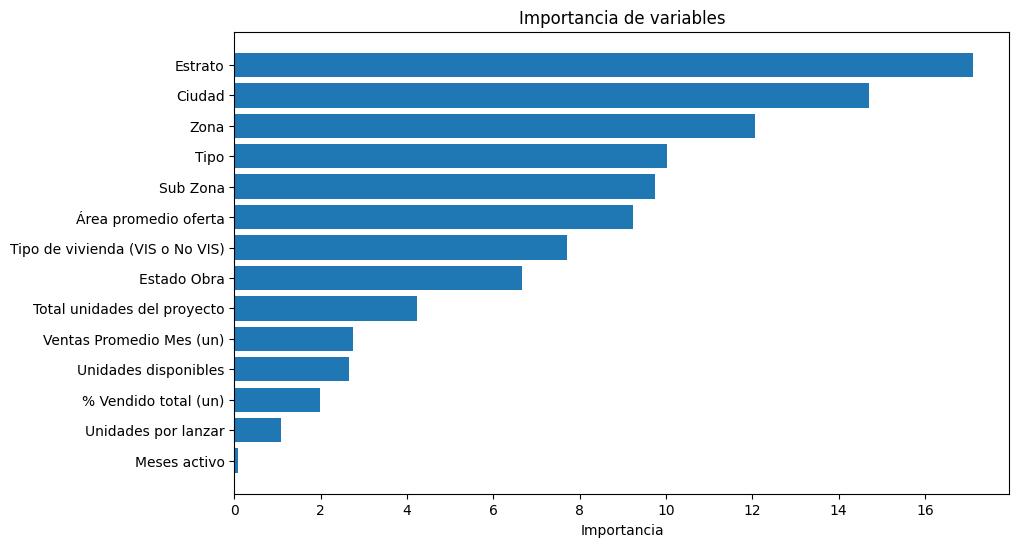


PREDICCIÓN NUEVO INMUEBLE
Precio estimado m²: 6521208.0


In [ ]:
 # ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor


# ============================================================
# 2. CARGAR EXCEL
# ============================================================

ruta = r"C:\Users\Usuario\Desktop\Trabajo Final Aprendizaje Maquinas\Base competitividad-Completa.xlsx"

df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
print(df.head())


# ============================================================
# 3. INSPECCIÓN INICIAL
# ============================================================

print("\nCOLUMNAS:")
print(df.columns.tolist())

print("\nNULOS:")
print(df.isnull().sum())

print("\nTIPOS:")
print(df.dtypes)


# ============================================================
# 4. SELECCIÓN DE VARIABLES
# TARGET = PRECIO M2
# ============================================================

columnas_modelo = [
    'Ciudad',
    'Zona',
    'Sub Zona',
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra',
    '$ Prom. Oferta m2'
]

df = df[columnas_modelo].copy()


# ============================================================
# 5. LIMPIEZA DE TARGET
# ============================================================

# eliminar target nulo
df = df[df['$ Prom. Oferta m2'].notnull()]

# convertir target a numérico
df['$ Prom. Oferta m2'] = pd.to_numeric(
    df['$ Prom. Oferta m2'],
    errors='coerce'
)

df = df[df['$ Prom. Oferta m2'].notnull()]

# eliminar valores absurdos
df = df[df['$ Prom. Oferta m2'] > 1000000]
df = df[df['$ Prom. Oferta m2'] < 50000000]


# ============================================================
# 6. LIMPIEZA VARIABLES NUMÉRICAS
# ============================================================

numericas = [
    'Estrato',
    'Área promedio oferta',
    'Meses activo',
    'Ventas Promedio Mes (un)',
    'Total unidades del proyecto',
    'Unidades disponibles',
    'Unidades por lanzar',
    '% Vendido total (un)'
]

for col in numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# ============================================================
# 7. IMPUTACIÓN DE NULOS
# ============================================================

# numéricas → mediana
for col in numericas:
    df[col] = df[col].fillna(df[col].median())

# categóricas → "Desconocido"
categoricas = [
    'Ciudad',
    'Zona',
    'Sub Zona',
    'Tipo',
    'Tipo de vivienda (VIS o No VIS)',
    'Estado Obra'
]

for col in categoricas:
    df[col] = df[col].fillna('Desconocido')


# ============================================================
# 8. ELIMINAR OUTLIERS (IQR)
# TARGET
# ============================================================

Q1 = df['$ Prom. Oferta m2'].quantile(0.25)
Q3 = df['$ Prom. Oferta m2'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df = df[
    (df['$ Prom. Oferta m2'] >= lim_inf) &
    (df['$ Prom. Oferta m2'] <= lim_sup)
]

print("\nDimensiones después limpieza:", df.shape)


# ============================================================
# 9. DEFINIR X E Y
# ============================================================

X = df.drop(columns=['$ Prom. Oferta m2'])
y = df['$ Prom. Oferta m2']


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 11. IDENTIFICAR CATEGÓRICAS PARA CATBOOST
# ============================================================

cat_features = [
    X.columns.get_loc('Ciudad'),
    X.columns.get_loc('Zona'),
    X.columns.get_loc('Sub Zona'),
    X.columns.get_loc('Tipo'),
    X.columns.get_loc('Tipo de vivienda (VIS o No VIS)'),
    X.columns.get_loc('Estado Obra')
]


# ============================================================
# 12. MODELO CATBOOST
# ============================================================

modelo = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

modelo.fit(
    X_train,
    y_train,
    cat_features=cat_features
)


# ============================================================
# 13. PREDICCIÓN TEST
# ============================================================

y_pred = modelo.predict(X_test)


# ============================================================
# 14. MÉTRICAS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\nRESULTADOS MODELO")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))
print("MAPE:", round(mape, 2), "%")


# ============================================================
# 15. CROSS VALIDATION CORRECTA PARA CATBOOST
# ============================================================

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = []

for train_idx, val_idx in kf.split(X):

    X_train_cv = X.iloc[train_idx]
    X_val_cv = X.iloc[val_idx]

    y_train_cv = y.iloc[train_idx]
    y_val_cv = y.iloc[val_idx]

    modelo_cv = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    modelo_cv.fit(
        X_train_cv,
        y_train_cv,
        cat_features=cat_features
    )

    pred_cv = modelo_cv.predict(X_val_cv)

    score = r2_score(y_val_cv, pred_cv)

    cv_scores.append(score)

print("\nCross Validation R²:")
print(cv_scores)
print("Promedio:", np.mean(cv_scores))


# ============================================================
# 16. IMPORTANCIA VARIABLES
# ============================================================

importancias = modelo.get_feature_importance()

imp_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

imp_df = imp_df.sort_values(
    by='Importancia',
    ascending=False
)

print("\nIMPORTANCIA VARIABLES")
print(imp_df)


# ============================================================
# 17. GRAFICAR IMPORTANCIA
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    imp_df['Variable'],
    imp_df['Importancia']
)

plt.gca().invert_yaxis()

plt.title('Importancia de variables')
plt.xlabel('Importancia')

plt.show()


# ============================================================
# 18. PREDICCIÓN NUEVO CASO
# EL POBLADO
# ============================================================

nuevo = pd.DataFrame({
    'Ciudad': ['Medellin'],
    'Zona': ['El Poblado'],
    'Sub Zona': ['Castropol'],
    'Estrato': [6],
    'Área promedio oferta': [95],
    'Meses activo': [2],
    'Ventas Promedio Mes (un)': [4],
    'Total unidades del proyecto': [180],
    'Unidades disponibles': [150],
    'Unidades por lanzar': [60],
    '% Vendido total (un)': [12],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Preventa']
})

pred = modelo.predict(nuevo)

print("\nPREDICCIÓN NUEVO INMUEBLE")
print("Precio estimado m²:", round(pred[0], 0))

In [6]:
print("\nRESULTADOS MODELO")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))
print("MAPE:", round(mape, 2), "%")


RESULTADOS MODELO
MAE: 536910.59
RMSE: 761061.69
R²: 0.9316
MAPE: 9.54 %


In [8]:
nuevo = pd.DataFrame({
    'Ciudad': ['Medellin'],
    'Zona': ['Envigado'],
    'Sub Zona': ['Las Vegas'],
    'Estrato': [5],
    'Área promedio oferta': [90],
    'Meses activo': [10],
    'Ventas Promedio Mes (un)': [12],
    'Total unidades del proyecto': [160],
    'Unidades disponibles': [35],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [78],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 6700259.0


In [9]:
nuevo = pd.DataFrame({
    'Ciudad': ['Medellin'],
    'Zona': ['El Poblado'],
    'Sub Zona': ['Milla de Oro'],
    'Estrato': [6],
    'Área promedio oferta': [110],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [10],
    'Total unidades del proyecto': [90],
    'Unidades disponibles': [12],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [87],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 6775654.0


In [10]:
nuevo = pd.DataFrame({
    'Ciudad': ['Medellin'],   # OJO: si tu base maneja SABANETA como ciudad, cambia a 'Sabaneta'
    'Zona': ['Sabaneta'],
    'Sub Zona': ['Aves Maria'],
    'Estrato': [4],
    'Área promedio oferta': [78],
    'Meses activo': [8],
    'Ventas Promedio Mes (un)': [9],
    'Total unidades del proyecto': [140],
    'Unidades disponibles': [28],
    'Unidades por lanzar': [0],
    '% Vendido total (un)': [80],
    'Tipo': ['Apartamento'],
    'Tipo de vivienda (VIS o No VIS)': ['No VIS'],
    'Estado Obra': ['Construcción']
})

pred = modelo.predict(nuevo)

print("Precio estimado m²:", round(pred[0], 0))

Precio estimado m²: 5629597.0
